# Graphic design 01

Macro idea → designer’s proposal and image prompt → generated poster → same designer
examines the poster → revises its proposal or prompt → next poster.

The designer judges whether visible choices communicate the macro idea, using semiotic
reasoning where helpful. Its own proposal is provisional. No independent critic is required.


## 1. Setup

Launch Jupyter from the repository root or this experiment directory. Install the project with `python -m pip install -e ".[notebook]"` first.
Load local configuration without displaying secrets. Existing process variables take priority,
then `.env.local`, then `.env`. The generation cell runs a paid API call only when `RUN_GENERATION` is set to `True`.


In [1]:
import os
import json
from pathlib import Path
from dotenv import dotenv_values
from copy import deepcopy
from IPython.display import Markdown, display
from graphic_design_helper.workflow import generate_round, design_round, load_rounds
from graphic_design_helper.images import compare_images
from graphic_design_helper.records import save_experiment, start_run

# Locate the repository from either its root or an experiment directory.
REPO_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pyproject.toml").is_file()
     and (path / "src/graphic_design_helper").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Launch Jupyter inside the graphic-design-helper repository.")
EXPERIMENT_DIR = REPO_ROOT / "experiments" / "pilot1"
OUTPUT_DIR = EXPERIMENT_DIR / "outputs"

local_config = {
    **dotenv_values(REPO_ROOT / ".env"),
    **dotenv_values(REPO_ROOT / ".env.local"),
}
for key, value in local_config.items():
    if value is not None:
        os.environ.setdefault(key, value)
del local_config
from graphic_design_helper.prompt_builder import build_designer_request, request_token
from graphic_design_helper.workflow import review_token, compose_prompt

from graphic_design_helper.proposal_presentation import render_design_rationale


## 2. Design task and requirements

Specify the communication purpose, audience, viewing context, deliverable, and constraints
below. These values populate the corresponding sections of the designer input template.
The internal `brief` variable stores these requirements; no separate brief document is needed.
Optional additional wording can be supplied through `original_user_request`.

New runs are created only when a designer call is enabled. To resume a new-format run,
set `run_dir` to its folder and use `rounds = load_rounds(run_dir)`. Restore the requirements
and original request from that run's records, then preview again. To start afresh,
reset `run_dir = None`, `rounds = []`, and `proposal_records = []`.


In [2]:
original_user_request = None  # Preserve a separate user request verbatim when supplied.
brief = {
    "core_message": None,  # Unspecified: the designer must not treat an inference as confirmed.
    "topic": "Slowing down in everyday life",
    "purpose": "Invite people to reconsider pressure to remain continuously productive and allow a brief pause.",
    "audience": "Students or office workers feeling pressure to stay productive.",
    "setting": "A poster encountered briefly in a shared indoor space.",
    "tone": "Inviting rather than blaming or patronizing.",
    "constraints": "Avoid unsupported factual, health, or society-wide claims.",
    "deliverable": "A portrait poster in English. Propose the visible wording.",
    "exact_copy": None,  # Supply text here only if it is a genuine requirement.
}
previous_headline = "A moment, without a project."  # Not included in the request.
if "rounds" not in globals():
    rounds = []
if "proposal_records" not in globals():
    proposal_records = []

if "run_dir" not in globals():
    run_dir = None


## 3. Preview the designer request

Initial proposals use `templates/designer-input-template.md`: the design task, audience,
requirements, design decisions, design approach, and proposal instructions.
Later rounds use `templates/designer-review-input-template.md`, which also receives the
previous proposal, the exact image prompt used, and the actual PNG as an image attachment.
The JSON response schema is shown separately because it is sent as the API's response
format. Editing instructions, schema, model settings, or the image requires a new preview.



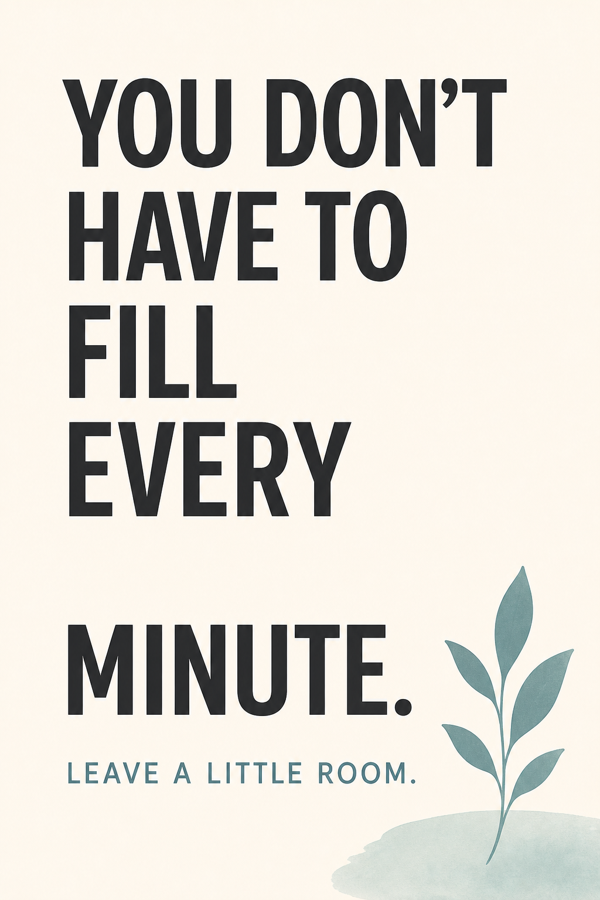

Act as a graphic designer informed by Peircean semiotics.
Start from the macro brief, not a predetermined motif or sign-category checklist.
Interpret the communication problem and state assumptions. Propose a direction and
give a concise, inspectable rationale. Include alternatives only when useful.
Explain what important elements refer to, how their relationships might support a
reading, and why graphic choices suit the audience and setting. Use iconic, indexical,
and symbolic relationships where relevant; do not force all three or assume fixed
meanings for colors and shapes. You may question whether depicting the topic literally
serves the purpose. Offer proposed wording unless exact copy is supplied in the brief.
Keep intended readings hypothetical. State uncertainties and visible review criteria.
A generated trace cannot establish documentary evidence. If the chosen direction
requires real sources or precise source composition, set status to needs_sources,
list those requirements, 

In [9]:
designer_model = os.getenv("OPENAI_DESIGNER_MODEL", "").strip() or "gpt-5.6-luna"
designer_effort = "medium"

def current_designer_request():
    revision_context = None
    designer_image = None
    if rounds:
        previous = rounds[-1]
        if brief != previous["research"]["brief"]:
            raise ValueError("The macro brief changed. Start a new run for a new communication objective.")
        if not previous.get("image_path"):
            raise ValueError("The last attempt has no image. Resolve that attempt before continuing.")
        revision_context = {
            "parent_folder": previous["folder"],
            "previous_proposal": previous["research"].get("proposal"),
            "previous_image_spec": previous.get("image_spec"),
            "previous_prompt": previous.get("image_prompt") or previous.get("generation", {}).get("prompt") or previous.get("production_prompt"),
        }
        designer_image = previous["image_path"]
    return build_designer_request(
        brief, revision_context, original_user_request=original_user_request,
        image_path=designer_image, model=designer_model, reasoning_effort=designer_effort,
    )

designer_request = current_designer_request()
designer_preview_token = request_token(designer_request)
print(designer_request["prompt"])
print(json.dumps({key: value for key, value in designer_request.items()
                  if key not in {"prompt", "designer_input"}}, ensure_ascii=False, indent=2))
if designer_request.get("image_path"):
    display(compare_images([designer_request["image_path"]], ["Poster for self-review"]))


## 4. Designer: propose, clarify, or review

Enable one paid designer call after reading the preview. No image call follows automatically.
If status is `needs_clarification` or `needs_sources`, supply the missing information
and return to the designer preview. `image_spec` remains null until the proposal is ready.
After self-review, inspect `revision_summary` and stop if no useful change is justified.
Each call is saved as a separate attempt, including failures and repeated proposals.


In [10]:
RUN_DESIGNER = True
if RUN_DESIGNER:
    if request_token(current_designer_request()) != designer_preview_token:
        raise ValueError("Inputs changed. Preview the designer request again.")
    if run_dir is None:
        run_dir = start_run(brief, original_user_request=original_user_request, output_dir=OUTPUT_DIR)
    proposal_record = design_round(
        designer_request, approved_token=designer_preview_token,
        run_dir=run_dir, history=rounds,
    )
    proposal_records.append(deepcopy(proposal_record))
    display(Markdown(render_design_rationale(proposal_record["proposal"])))
    print(f"Saved designer attempt: {proposal_record['folder']}")
else:
    print("Designer call is off. Preview the request, then enable when ready.")


{
  "status": "ready",
  "brief_interpretation": "The poster should gently interrupt the assumption that every moment must be productive. It needs to communicate permission for a brief pause quickly, without sounding anti-work, therapeutic, or judgmental.",
  "chosen_direction": "Retain the strong typographic interruption: a large, orderly sentence is split by a conspicuous field of empty space before “MINUTE.” Remove the illustrative plant so the pause itself remains the primary visual event.",
  "design_rationale": "The generated poster communicates the message clearly at a glance: the large dark type is highly legible, the sentence is complete, and the unusually large gap creates a felt interruption in reading. The warm background and restrained blue-green support an inviting tone. However, the plant and its shadow introduce a secondary nature/growth narrative that is not necessary to the macro brief and may make the poster read as a general wellness or botanical message. A purely t

## 5. Review two deliverables: design rationale and image prompt

Read the design rationale first: the communication purpose, sign relationships,
intended readings, stylistic choices, uncertainties, and visible review criteria.
It is saved as `design-rationale.md` alongside the designer's `proposal.json`.

The editable image specification below is the second deliverable. Its assembled
prompt is what the image model receives; the design explanation is not sent to it.
You may edit `image_spec` without changing the saved model proposal. If an edit changes
the concept or its sign relationships, revisit the design explanation before approval.
Rerun the separate preview cell after edits. Reinitializing the draft discards unsaved edits.


In [11]:
image_spec = deepcopy(proposal_record["proposal"]["image_spec"]) if "proposal_record" in globals() else None
image_settings = {
    "model": os.getenv("OPENAI_IMAGE_MODEL", "gpt-image-2"),
    "size": "1024x1536", "quality": "medium",
}
reviewed_token = None

def current_research():
    if "proposal_record" not in globals():
        raise ValueError("Request a design proposal first.")
    inputs = proposal_record["designer_input"]
    if brief != inputs["brief"] or original_user_request != inputs["original_user_request"]:
        raise ValueError("The user input changed. Request a new proposal.")
    return deepcopy({"brief": brief, "original_user_request": original_user_request,
                     "proposal": proposal_record["proposal"], "designer_record": proposal_record})

print(json.dumps(image_spec, ensure_ascii=False, indent=2))


Create a portrait English poster inviting people under everyday productivity pressure to allow a brief pause. Visible copy exactly: “YOU DON’T HAVE TO FILL EVERY MINUTE.” and “LEAVE A LITTLE ROOM.” Set the main copy in very large, highly legible dark charcoal sans-serif type on a warm off-white background, with a calm left-aligned grid and a generous intentional vertical gap between “EVERY” and “MINUTE” so the sentence visibly pauses. Place “LEAVE A LITTLE ROOM.” beneath the main copy in smaller muted blue-green sans-serif type with generous whitespace. Preserve strong hierarchy, accurate spelling and punctuation, and readability from several feet away. Allow subtle variations in typeface and spacing while preserving the exact copy, portrait format, typographic pause, and inviting tone. Exclude plants, illustrations, shadows, clocks, phones, office scenes, busy patterns, alarmist or guilt-inducing language, extra text, illegible typography, and ornate decoration.
{'model': 'gpt-image-2

In [ ]:
# Rerun this cell after editing image_spec or the image prompt templates.
image_prompt_preview = compose_prompt(image_spec) if image_spec is not None else None
image_preview_context = request_token([image_spec, current_research(), image_settings]) if image_spec is not None else None
display(Markdown("# Image generation prompt\n\n" + image_prompt_preview)) if image_prompt_preview is not None else print("No ready image specification. Review the design rationale first.")
print(image_settings)


In [12]:
MARK_PROMPT_REVIEWED = True
if MARK_PROMPT_REVIEWED:
    if image_prompt_preview is None:
        raise ValueError("Resolve clarification or sources, then preview a ready specification.")
    if request_token([image_spec, current_research(), image_settings]) != image_preview_context:
        raise ValueError("Draft, rationale, or settings changed. Preview again.")
    reviewed_token = review_token(image_spec, current_research(), image_settings,
                                  image_prompt=image_prompt_preview)
    print("Complete image request and research marked reviewed.")


Current prompt, rationale, and settings marked reviewed.


## 6. Generate the poster

Enable one generation after inspecting the proposed prompt. This experiment retains the
limit of one initial attempt and two revisions. Each request saves its proposal, prompt and image.
The next poster is generated from the updated text prompt; this notebook does not edit the
previous image's pixels. The previous image is visual input to the designer's self-review.


In [13]:
RUN_GENERATION = True
if RUN_GENERATION:
    research = current_research()
    revision_decision = {
        "reason": research["proposal"]["revision_summary"] if rounds else "Initial proposal",
    }
    active_round = generate_round(
        image_spec, research, image_settings,
        approved_token=reviewed_token, history=rounds, revision=revision_decision,
        output_dir=OUTPUT_DIR,
    )
    reviewed_token = None
    print(f"Saved round {active_round['round']} to {active_round['folder']}")
else:
    print("Image generation is off.")


Saved round 2 to D:\DH-Research\graphic-design-helper\outputs\20260905T115319Z_51353534



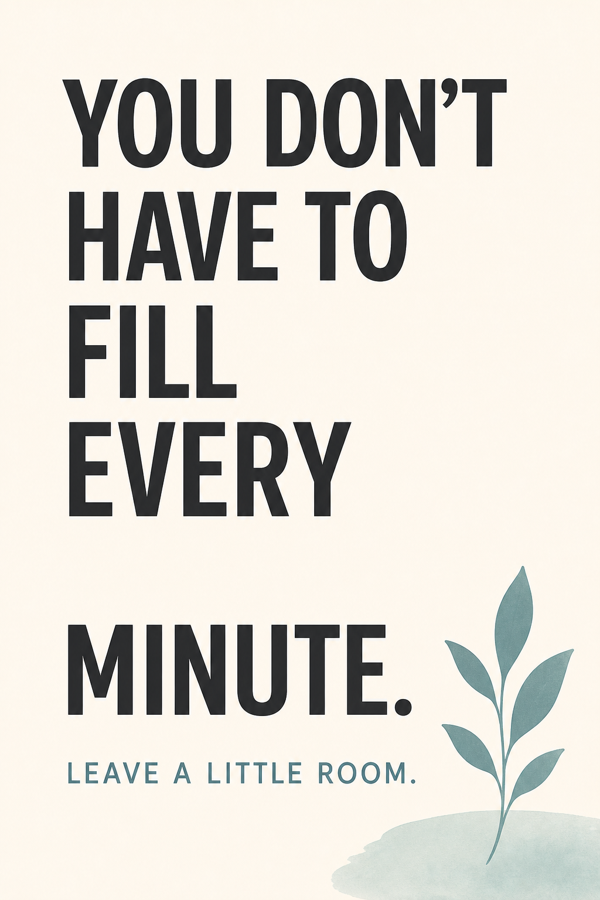
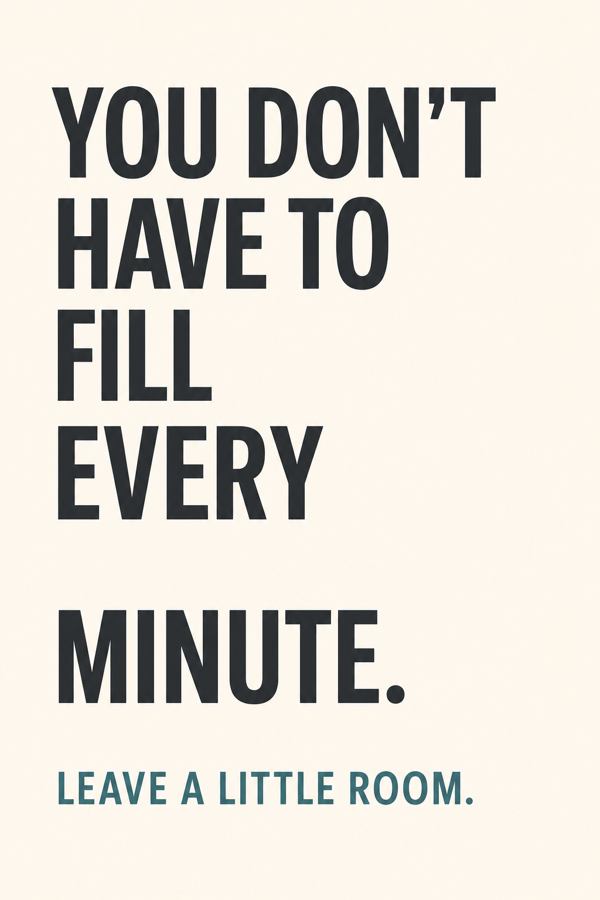

In [14]:
image_paths = [r["image_path"] for r in rounds if r.get("image_path")]
labels = [f"Round {r['round']}" for r in rounds if r.get("image_path")]
if image_paths:
    display(compare_images(image_paths, labels))


## 7. Look, reconsider, repeat

Return to Section 3 for self-review of the latest poster against the original brief.
Keep successful choices and stop when no useful change remains. The limit is three
image attempts, including failed or uncertain calls; reaching it does not establish success.
A model's reading is a design judgment, not evidence of audience reception.

New records are grouped under `outputs/<run_id>/rounds/<number>/`. Each `designer/`
and `image/` directory contains separate `attempt_*` folders with `request.json`,
`prompt.md`, and `response.json`. Designer attempts save `proposal.json`; image attempts
save the reviewed `image-spec.json` and `image.png`. The original proposal is preserved.

Use `load_rounds(run_dir)` after a restart. Historical outputs remain unchanged and
can be inspected directly; do not rerun them just to adopt the new record structure.


## 8. Optional audience readings

Before explaining the intention, ask: What did you notice first? What do you think this is saying?
Who seems to be speaking? Does it invite you to do anything? Record unexpected readings too.
These are exploratory observations, not evidence of long-term behavior change.

Store participants' words separately from your interpretation. Avoid identifying information.

For each element, compare the intended relationship with the reading people actually describe.
Ask about the imagery and arrangement in ordinary language; viewers need not know Peircean terms.
If something looks like evidence, ask what they think it documents. Do not supply that answer first.


In [ ]:
observations = []  # For each response: variant, anonymous label, verbatim wording, researcher interpretation.
reflection = {
    "what_worked": "",
    "unexpected_readings": "",
    "design_changes_to_try": "",
    "semiotic_assumptions_to_revisit": "",
    "relations_supported_or_challenged_by_responses": "",
    "source_or_evidence_confusions": "",
    "limitations": "No audience responses recorded in this reflection.",
}


## 9. Save a snapshot

Set `SAVE_SNAPSHOT` to `True` when you want to save the current state. Each save creates a new folder
with notes, image copies, and hashes. Include only non-secret settings; never pass environment
variables, API keys, or client objects. The saved status distinguishes planning from collected evidence.


In [ ]:
SAVE_SNAPSHOT = False
if SAVE_SNAPSHOT:
    run = save_experiment({
        "status": "exploration" if rounds else "planning",
        "brief": brief, "designer_request": designer_request,
        "proposal_records": proposal_records,
        "image_spec_draft": image_spec, "rounds": rounds,
        "audience_observations": observations, "reflection": reflection,
    }, [r["image_path"] for r in rounds if r.get("image_path")], OUTPUT_DIR)
    print(f"Saved: {run}")
